In [1]:
%pip install -e "c:\Users\LIONESS\Desktop\e-waste\segment-anything"

Obtaining file:///C:/Users/LIONESS/Desktop/e-waste/segment-anything
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for segment_anything (pyproject.toml): started
  Building editable for segment_anything (pyproject.toml): finished with status 'done'
  Created wheel for segment_anything: filename=segment_anything-1.0-0.editable-py3-none-any.whl size=7088 sha256=080342729395d9d33d0ce61c1deadeacf4dce70f6c8bfbcc7544a561b3b6402f
  Stored in directory: C:\Users\LIONESS\AppData\Local\Temp\pip-ephem-wheel-cache-9xrdah5l\wheels\e0\22\c

In [2]:
import sys
sys.path.append("segment-anything")

In [3]:
from segment_anything import sam_model_registry, SamPredictor
print("SAM imported successfully")

SAM imported successfully


In [4]:
from segment_anything import sam_model_registry
print("SAM installed successfully")

SAM installed successfully


In [5]:
import os
import numpy as np
from pathlib import Path
from tqdm import tqdm

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

In [7]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


In [8]:
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

In [9]:
try:
    from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
    SAM_AVAILABLE = True
except ImportError:
    SAM_AVAILABLE = False
    print("⚠️  SAM not installed. Run: pip install git+https://github.com/facebookresearch/segment-anything.git")

In [10]:
CONFIG = {
    "dataset_path":   "TrashBox_train_set",
    "output_path":    "outputs/dinov2_sam",
    "sam_checkpoint": "sam_vit_h_4b8939.pth",   # Download from Meta
    "sam_model_type": "vit_b",                   # vit_h, vit_l, or vit_b
    "dinov2_model":   "dinov2_vits14",           # or dinov2_vits14 (smaller/faster)
    "num_clusters":   6,                          # Number of trash categories
    "batch_size":     4,
    "image_size":     224,
    "device":         "cuda" if torch.cuda.is_available() else "cpu",
    "feature_dim":    768,                        # DINOv2 ViT-B output dim
}

CLASS_NAMES = ['cardboard', 'e-waste', 'glass', 'medical', 'metal', 'paper', 'plastic']

print(f"Using device: {CONFIG['device']}")
os.makedirs(CONFIG["output_path"], exist_ok=True)

Using device: cpu


In [11]:
def load_dinov2(model_name="dinov2_vits14"):
    """
    Loads DINOv2 pretrained Vision Transformer from Facebook Research.
    No labels needed — pretrained on 142M images via self-supervised learning.
    """
    print(f"\n🔄 Loading DINOv2 ({model_name})...")
    model = torch.hub.load("facebookresearch/dinov2", model_name)
    model.eval()
    model = model.to(CONFIG["device"])
    print("✅ DINOv2 loaded successfully!")
    return model


In [12]:
class TrashDataset(Dataset):
    """Loads trash images from class subfolders."""

    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        self.labels      = []
        self.class_names = sorted(os.listdir(root_dir))
        self.transform   = transform or transforms.Compose([
            transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225]),
        ])

        for class_idx, class_name in enumerate(self.class_names):
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
            for img_file in Path(class_dir).glob("*"):
                if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']:
                    self.image_paths.append(str(img_file))
                    self.labels.append(class_idx)

        print(f"  Loaded {len(self.image_paths)} images across "
              f"{len(self.class_names)} classes")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        return self.transform(image), self.labels[idx], self.image_paths[idx]


In [13]:
def extract_dinov2_features(model, dataset):
    """
    Extracts DINOv2 feature embeddings for all images.
    These features capture material texture, shape, and color —
    perfect for distinguishing trash types.
    No labels used during extraction.
    """
    print("\n🧠 Extracting DINOv2 features (no labels used)...")
    loader = DataLoader(dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

    all_features = []
    all_labels   = []
    all_paths    = []

    with torch.no_grad():
        for images, labels, paths in tqdm(loader, desc="Extracting features"):
            images   = images.to(CONFIG["device"])
            features = model(images)               # Shape: (B, 768)
            all_features.append(features.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_paths.extend(paths)

    features = np.vstack(all_features)
    features = normalize(features)                 # L2 normalize
    labels   = np.array(all_labels)

    print(f"  Feature matrix shape: {features.shape}")
    np.save(f"{CONFIG['output_path']}/dinov2_features.npy", features)
    np.save(f"{CONFIG['output_path']}/true_labels.npy", labels)
    print(f"  Features saved to {CONFIG['output_path']}/")

    return features, labels, all_paths

In [14]:
def cluster_features(features, labels, n_clusters=6):
    """
    Clusters DINOv2 features using K-Means.
    Evaluates against true labels using ARI and NMI scores.
    This is the SCAN-inspired step — no labels used for training.
    """
    print(f"\n📊 Clustering into {n_clusters} trash categories...")

    # K-Means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(features)

    # Evaluate clustering quality (using labels only for evaluation)
    ari = adjusted_rand_score(labels, cluster_labels)
    nmi = normalized_mutual_info_score(labels, cluster_labels)

    print(f"  Adjusted Rand Index (ARI): {ari:.4f}  (1.0 = perfect)")
    print(f"  Normalized Mutual Info (NMI): {nmi:.4f}  (1.0 = perfect)")

    np.save(f"{CONFIG['output_path']}/cluster_labels.npy", cluster_labels)
    return cluster_labels, kmeans, ari, nmi


In [40]:
def visualize_features(features, labels, cluster_labels):
    """Visualizes DINOv2 features using t-SNE or UMAP."""
    print("\n🎨 Visualizing feature space...")

    import numpy as np
    import matplotlib.pyplot as plt

    if UMAP_AVAILABLE:
        print("  Using UMAP...")
        reducer = umap.UMAP(n_components=2, random_state=42)
        reduced = reducer.fit_transform(features)
        method = "UMAP"
    else:
        print("  Using t-SNE...")
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        reduced = tsne.fit_transform(features[:2000])
        labels = labels[:2000]
        cluster_labels = cluster_labels[:2000]
        method = "t-SNE"

    n_true_classes = len(np.unique(labels))
    n_cluster_classes = len(np.unique(cluster_labels))
    n_colors = max(n_true_classes, n_cluster_classes, CONFIG["num_clusters"])

    colors = plt.cm.tab10(np.linspace(0, 1, n_colors))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for i, cls in enumerate(np.unique(labels)):
        mask = labels == cls
        name = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else f"class_{cls}"
        ax1.scatter(
            reduced[mask, 0],
            reduced[mask, 1],
            c=[colors[i % len(colors)]],
            label=name,
            alpha=0.6,
            s=10
        )

    ax1.set_title(f"True Labels ({method})")
    ax1.legend(markerscale=2, fontsize=8)

    for i, cls in enumerate(np.unique(cluster_labels)):
        mask = cluster_labels == cls
        ax2.scatter(
            reduced[mask, 0],
            reduced[mask, 1],
            c=[colors[i % len(colors)]],
            label=f"Cluster {cls}",
            alpha=0.6,
            s=10
        )

    ax2.set_title(f"DINOv2 Clusters ({method})")
    ax2.legend(markerscale=2, fontsize=8)

    plt.suptitle("DINOv2 Feature Space — Trash Dataset", fontsize=14)
    plt.tight_layout()
    save_path = f"{CONFIG['output_path']}/feature_visualization.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"  Visualization saved: {save_path}")
    plt.show()

In [41]:
def load_sam(checkpoint_path, model_type="vit_h"):
    """
    Loads Meta's Segment Anything Model (SAM).
    SAM can segment any object in an image without task-specific training.
    """
    if not SAM_AVAILABLE:
        print("⚠️  SAM not available. Skipping segmentation step.")
        return None

    if not os.path.exists(checkpoint_path):
        print(f"⚠️  SAM checkpoint not found at: {checkpoint_path}")
        print("   Download it with:")
        print("   wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth")
        return None

    print(f"\n🔄 Loading SAM ({model_type})...")
    sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
    sam = sam.to(CONFIG["device"])
    print("✅ SAM loaded successfully!")
    return sam

In [42]:
def segment_and_classify(image_path, sam, dinov2_model, kmeans):
    """
    Full pipeline for a single image:
    1. SAM segments individual trash items
    2. DINOv2 extracts features for each segment
    3. K-Means assigns trash category to each segment
    """
    if sam is None:
        print("SAM not available — skipping segmentation.")
        return None

    # Load image
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # Step 1: Segment with SAM (automatic mask generation)
    mask_generator = SamAutomaticMaskGenerator(
        sam,
        points_per_side=16,          # Fewer points = faster
        pred_iou_thresh=0.88,
        stability_score_thresh=0.95,
        min_mask_region_area=500,    # Filter tiny segments
    )
    masks = mask_generator.generate(image_rgb)
    print(f"  Found {len(masks)} segments in image")

    transform = transforms.Compose([
        transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                              [0.229, 0.224, 0.225]),
    ])

    results = []

    for mask_data in masks:
        mask     = mask_data["segmentation"]
        bbox     = mask_data["bbox"]          # [x, y, w, h]
        area     = mask_data["area"]

        # Crop segment from image using bounding box
        x, y, w, h = [int(v) for v in bbox]
        crop = image_rgb[y:y+h, x:x+w]

        if crop.size == 0:
            continue

        # Step 2: Extract DINOv2 features for this segment
        crop_pil   = Image.fromarray(crop)
        crop_tensor = transform(crop_pil).unsqueeze(0).to(CONFIG["device"])

        with torch.no_grad():
            features = dinov2_model(crop_tensor).cpu().numpy()
            features = normalize(features)

        # Step 3: Classify using K-Means
        cluster_id  = kmeans.predict(features)[0]
        class_name  = CLASS_NAMES[cluster_id] if cluster_id < len(CLASS_NAMES) \
                      else f"cluster_{cluster_id}"

        results.append({
            "bbox":       bbox,
            "area":       area,
            "cluster_id": cluster_id,
            "class_name": class_name,
            "mask":       mask,
        })

    return results, image_rgb

In [43]:
def visualize_segmentation(image_rgb, results, save_path):
    """Draws segmentation results on the image."""
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(image_rgb)

    colors = plt.cm.tab10(np.linspace(0, 1, CONFIG["num_clusters"]))

    for result in results:
        x, y, w, h     = result["bbox"]
        class_name      = result["class_name"]
        cluster_id      = result["cluster_id"]
        color           = colors[cluster_id % len(colors)]

        # Draw bounding box
        rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                   edgecolor=color,
                                   facecolor="none")
        ax.add_patch(rect)

        # Draw label
        ax.text(x, y - 5, class_name,
                color="white", fontsize=9,
                bbox=dict(facecolor=color, alpha=0.7, pad=2))

        # Draw mask overlay
        mask_overlay          = np.zeros((*image_rgb.shape[:2], 4))
        mask_overlay[result["mask"]] = [*color[:3], 0.3]
        ax.imshow(mask_overlay)

    ax.set_title("SAM Segmentation + DINOv2 Classification", fontsize=14)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"  Segmentation result saved: {save_path}")
    plt.close()


In [44]:
class DINOv2Classifier(nn.Module):
    """
    Adds a lightweight classification head on top of frozen DINOv2.
    Use this if you want to fine-tune with a small number of labels.
    """

    def __init__(self, dinov2_model, num_classes, freeze_backbone=True):
        super().__init__()
        self.backbone = dinov2_model

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Linear(CONFIG["feature_dim"], 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        with torch.no_grad():
            features = self.backbone(x)
        return self.classifier(features)

In [45]:
class WasteLevelPredictor(nn.Module):
    """
    Predicts fill level (0.0 = empty, 1.0 = full) from DINOv2 features.
    Train with images labeled by fill percentage.
    """

    def __init__(self):
        super().__init__()
        self.predictor = nn.Sequential(
            nn.Linear(CONFIG["feature_dim"], 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()    # Output 0.0 to 1.0
        )

    def forward(self, features):
        return self.predictor(features)


In [46]:
from PIL import Image, UnidentifiedImageError
import os

bad_files = []

for root, dirs, files in os.walk("TrashBox_train_set"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            path = os.path.join(root, file)
            try:
                with Image.open(path) as img:
                    img.verify()
            except (UnidentifiedImageError, OSError, SyntaxError) as e:
                bad_files.append(path)

print(f"Bad files found: {len(bad_files)}")
for f in bad_files:
    print(f)

Bad files found: 0


In [47]:
for f in bad_files:
    os.remove(f)
    print("Deleted:", f)


🗑️  Trash Detection & Classification — DINOv2 + SAM

📂 Step 1: Loading trash dataset...
  Loaded 14279 images across 7 classes

🔄 Step 2: Loading DINOv2...

🔄 Loading DINOv2 (dinov2_vits14)...


Using cache found in C:\Users\LIONESS/.cache\torch\hub\facebookresearch_dinov2_main


✅ DINOv2 loaded successfully!

🧠 Step 3: Extracting DINOv2 features (no labels used)...
Loading cached DINOv2 features...

📊 Step 4: Clustering trash categories...

📊 Clustering into 6 trash categories...
  Adjusted Rand Index (ARI): 0.3857  (1.0 = perfect)
  Normalized Mutual Info (NMI): 0.5224  (1.0 = perfect)

🎨 Step 5: Visualizing feature space...

🎨 Visualizing feature space...
  Using UMAP...


c:\Users\LIONESS\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Visualization saved: outputs/dinov2_sam/feature_visualization.png


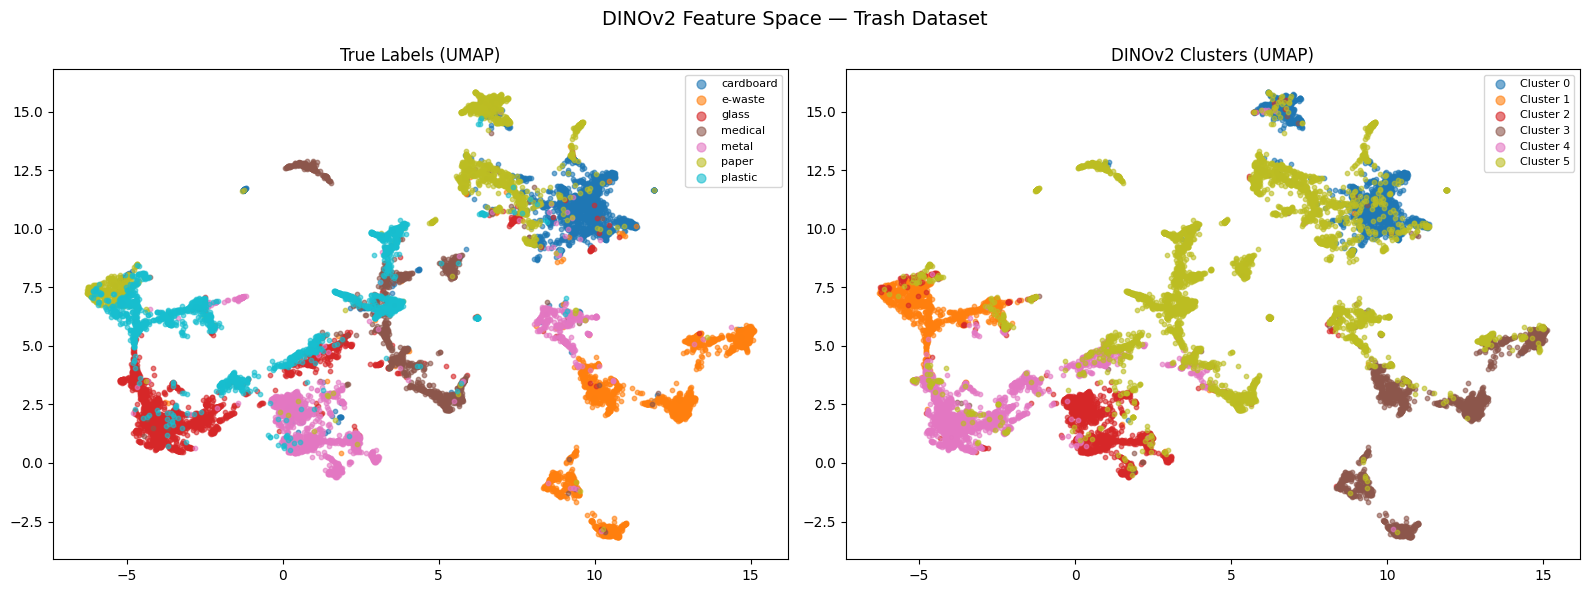


🔍 Step 6: Loading SAM for segmentation...
⚠️  SAM checkpoint not found at: sam_vit_h_4b8939.pth
   Download it with:
   wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

🎯 Step 8: Building fine-tunable classifier head...
  Classifier ready. Use with labeled subset if available.
  Backbone frozen = True (efficient fine-tuning)

✅ DINOv2 + SAM Pipeline Complete!
  Clustering ARI:  0.3857  (higher = better)
  Clustering NMI:  0.5224  (higher = better)
  Results saved to: outputs/dinov2_sam/

Output files:
  - dinov2_features.npy        (raw feature embeddings)
  - cluster_labels.npy         (cluster assignments)
  - feature_visualization.png  (t-SNE/UMAP plot)
  - segmentation_result_*.png  (SAM + classification results)

💡 Next steps:
  1. Review feature_visualization.png — are clusters well separated?
  2. Label a small subset based on cluster groups
  3. Fine-tune DINOv2Classifier with those labels for higher accuracy


In [48]:
if __name__ == "__main__":

    print("\n🗑️  Trash Detection & Classification — DINOv2 + SAM")
    print("="*55)

    # -----------------------------------------------------------
    # PART A: Unsupervised Feature Extraction + Clustering
    # -----------------------------------------------------------
    print("\n📂 Step 1: Loading trash dataset...")
    dataset = TrashDataset(CONFIG["dataset_path"])

    print("\n🔄 Step 2: Loading DINOv2...")
    dinov2 = load_dinov2(CONFIG["dinov2_model"])

    print("\n🧠 Step 3: Extracting DINOv2 features (no labels used)...")
    import os
    import numpy as np

    feature_file = f"{CONFIG['output_path']}/dinov2_features.npy"
    label_file = f"{CONFIG['output_path']}/true_labels.npy"

    if os.path.exists(feature_file) and os.path.exists(label_file):
        print("Loading cached DINOv2 features...")
        features = np.load(feature_file)
        true_labels = np.load(label_file)
    else:
        print("Extracting DINOv2 features...")
        features, true_labels, image_paths = extract_dinov2_features(dinov2, dataset)

    print("\n📊 Step 4: Clustering trash categories...")
    cluster_labels, kmeans, ari, nmi = cluster_features(
        features, true_labels, n_clusters=CONFIG["num_clusters"]
    )

    print("\n🎨 Step 5: Visualizing feature space...")
    visualize_features(features, true_labels, cluster_labels)

    # -----------------------------------------------------------
    # PART B: SAM Segmentation on Sample Images
    # -----------------------------------------------------------
    print("\n🔍 Step 6: Loading SAM for segmentation...")
    sam = load_sam(CONFIG["sam_checkpoint"], CONFIG["sam_model_type"])

    if sam and image_paths:
        print("\n🖼️  Step 7: Running SAM + DINOv2 on sample images...")
        sample_images = image_paths[:3]    # Test on first 3 images

        for i, img_path in enumerate(sample_images):
            print(f"\n  Processing image {i+1}: {os.path.basename(img_path)}")
            results, image_rgb = segment_and_classify(img_path, sam, dinov2, kmeans)
            if results:
                save_path = f"{CONFIG['output_path']}/segmentation_result_{i+1}.png"
                visualize_segmentation(image_rgb, results, save_path)
                print(f"  Detected {len(results)} trash items:")
                for r in results:
                    print(f"    → {r['class_name']} (area: {r['area']} px)")

    # -----------------------------------------------------------
    # PART C: Optional Fine-tuned Classifier (with few labels)
    # -----------------------------------------------------------
    print("\n🎯 Step 8: Building fine-tunable classifier head...")
    classifier = DINOv2Classifier(
        dinov2_model=dinov2,
        num_classes=CONFIG["num_clusters"],
        freeze_backbone=True     # Only train the head, keep DINOv2 frozen
    ).to(CONFIG["device"])

    print("  Classifier ready. Use with labeled subset if available.")
    print("  Backbone frozen = True (efficient fine-tuning)")

    # -----------------------------------------------------------
    # SUMMARY
    # -----------------------------------------------------------
    print("\n" + "="*55)
    print("✅ DINOv2 + SAM Pipeline Complete!")
    print("="*55)
    print(f"  Clustering ARI:  {ari:.4f}  (higher = better)")
    print(f"  Clustering NMI:  {nmi:.4f}  (higher = better)")
    print(f"  Results saved to: {CONFIG['output_path']}/")
    print("\nOutput files:")
    print("  - dinov2_features.npy        (raw feature embeddings)")
    print("  - cluster_labels.npy         (cluster assignments)")
    print("  - feature_visualization.png  (t-SNE/UMAP plot)")
    print("  - segmentation_result_*.png  (SAM + classification results)")
    print("\n💡 Next steps:")
    print("  1. Review feature_visualization.png — are clusters well separated?")
    print("  2. Label a small subset based on cluster groups")
    print("  3. Fine-tune DINOv2Classifier with those labels for higher accuracy")


In [ ]:
feature_file = os.path.join(CONFIG["output_path"], "dinov2_features.npy")
label_file = os.path.join(CONFIG["output_path"], "true_labels.npy")

features = np.load(feature_file)
labels = np.load(label_file)

print("Features shape:", features.shape)   
print("Labels shape:", labels.shape)
print("Unique labels:", np.unique(labels))

Features shape: (14279, 384)
Labels shape: (14279,)
Unique labels: [0 1 2 3 4 5 6]


In [51]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)

Train: (11423, 384) (11423,)
Val:   (2856, 384) (2856,)


In [52]:
class FeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [53]:
train_dataset = FeatureDataset(X_train, y_train)
val_dataset = FeatureDataset(X_val, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

In [54]:
class FeatureClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [58]:
CONFIG["num_classes"] = len(CLASS_NAMES)

device = "cpu"
input_dim = features.shape[1]

classifier = FeatureClassifier(
    input_dim=input_dim,
    num_classes=CONFIG["num_classes"]
).to(device)

print(classifier)

FeatureClassifier(
  (net): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=7, bias=True)
  )
)


In [60]:
from sklearn.metrics import accuracy_score


def train_one_epoch(model, loader, criterion, optimizer, device="cpu"):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device="cpu"):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

In [62]:
import copy

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 20
best_val_acc = 0.0
best_model_state = copy.deepcopy(classifier.state_dict())

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

print("\nStarting classifier training...\n")

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        classifier, train_loader, criterion, optimizer, device=device
    )

    val_loss, val_acc, val_preds, val_true = evaluate(
        classifier, val_loader, criterion, device=device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1:02d}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(classifier.state_dict())
        torch.save(
            best_model_state,
            os.path.join(CONFIG["output_path"], "best_feature_classifier.pth")
        )
        print(f"  Saved new best model with val acc = {val_acc:.4f}")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")


Starting classifier training...

Epoch [01/20] | Train Loss: 0.8751 | Train Acc: 0.8022 | Val Loss: 0.3159 | Val Acc: 0.9139
  Saved new best model with val acc = 0.9139
Epoch [02/20] | Train Loss: 0.2684 | Train Acc: 0.9196 | Val Loss: 0.2338 | Val Acc: 0.9272
  Saved new best model with val acc = 0.9272
Epoch [03/20] | Train Loss: 0.2171 | Train Acc: 0.9326 | Val Loss: 0.2112 | Val Acc: 0.9303
  Saved new best model with val acc = 0.9303
Epoch [04/20] | Train Loss: 0.1913 | Train Acc: 0.9380 | Val Loss: 0.2015 | Val Acc: 0.9345
  Saved new best model with val acc = 0.9345
Epoch [05/20] | Train Loss: 0.1759 | Train Acc: 0.9434 | Val Loss: 0.1937 | Val Acc: 0.9373
  Saved new best model with val acc = 0.9373
Epoch [06/20] | Train Loss: 0.1627 | Train Acc: 0.9485 | Val Loss: 0.1906 | Val Acc: 0.9342
Epoch [07/20] | Train Loss: 0.1531 | Train Acc: 0.9519 | Val Loss: 0.1891 | Val Acc: 0.9356
Epoch [08/20] | Train Loss: 0.1450 | Train Acc: 0.9527 | Val Loss: 0.1847 | Val Acc: 0.9387
  Sav

In [65]:
from sklearn.metrics import classification_report

classifier.load_state_dict(best_model_state)

val_loss, val_acc, val_preds, val_true = evaluate(
    classifier, val_loader, criterion, device=device
)

print("\nFinal Validation Accuracy:", val_acc)
print("\nClassification Report:\n")
print(classification_report(val_true, val_preds, target_names=CLASS_NAMES))


Final Validation Accuracy: 0.9418767507002801

Classification Report:

              precision    recall  f1-score   support

   cardboard       0.92      0.91      0.91       386
     e-waste       0.99      0.99      0.99       481
       glass       0.96      0.92      0.94       404
     medical       0.95      0.95      0.95       313
       metal       0.96      0.95      0.96       414
       paper       0.92      0.92      0.92       431
     plastic       0.90      0.94      0.92       427

    accuracy                           0.94      2856
   macro avg       0.94      0.94      0.94      2856
weighted avg       0.94      0.94      0.94      2856



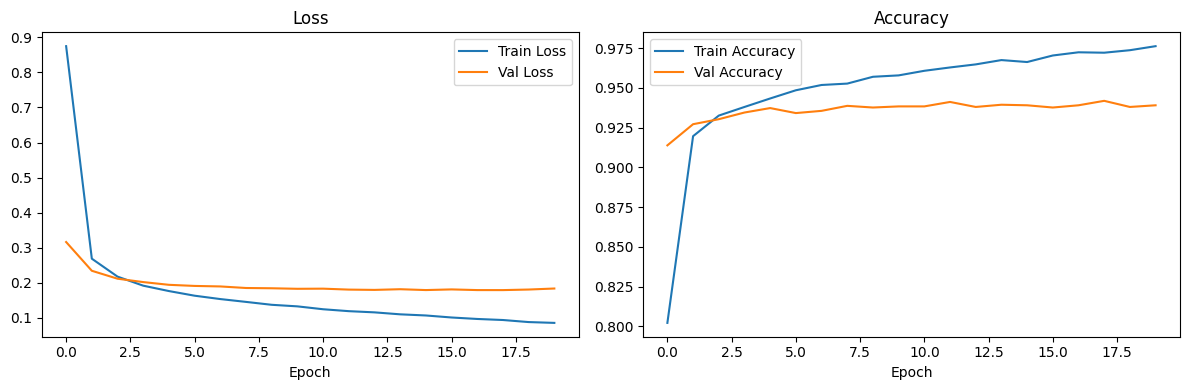

Training curves saved to: outputs/dinov2_sam\classifier_training_curves.png


In [66]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plot_path = os.path.join(CONFIG["output_path"], "classifier_training_curves.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Training curves saved to:", plot_path)

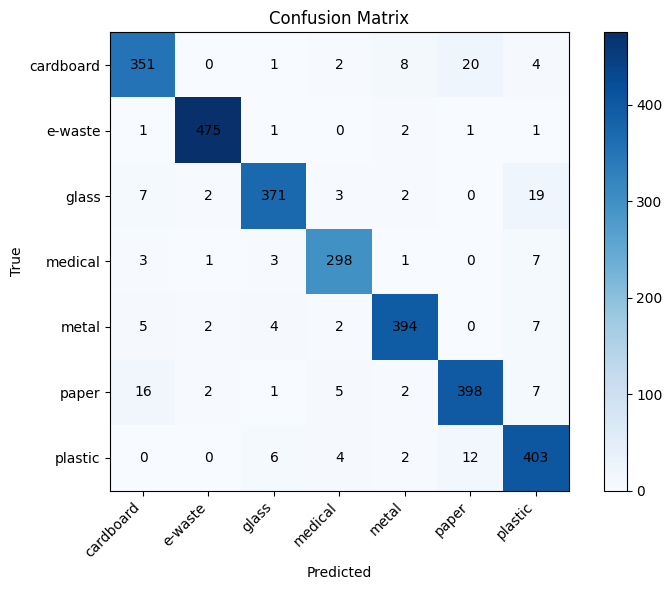

Confusion matrix saved to: outputs/dinov2_sam\confusion_matrix.png


In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_true, val_preds)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45, ha="right")
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()

cm_path = os.path.join(CONFIG["output_path"], "confusion_matrix.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

print("Confusion matrix saved to:", cm_path)